In [1]:
import pandas as pd
df = pd.read_csv("dataset_backwash_withtime.csv", index_col="time", parse_dates=True)


In [2]:
df.head()

,INTAKE LINE PRESSURE OF HMMF FEED PUMPS,FIT_001A_FLOW AT INLET HMMF-A,FIT_001B_FLOW AT INLET HMMF-B,FIT_001C_FLOW AT INLET HMMF-C,FIT_001D_FLOW AT INLET HMMF-D,FIT_001E_FLOW AT INLET HMMF-E,FIT_001F_FLOW AT INLET HMMF-F,FIT_001G_FLOW AT INLET HMMF-G,FIT_001H_FLOW AT INLET HMMF-H,FIT_001I_FLOW AT INLET HMMF-I,...,FIT_005E_PERMEATE FLOW,FIT_005F_PERMEATE FLOW,FIT_005G_PERMEATE FLOW,FIT_005H_PERMEATE FLOW,INDICE_ENCRASSEMENT_HMMF,DEBIT_ENTREE_HMMF,INDICE_IMPACT_PRODUCTION,INDICE_DESEQUILIBRE_FILTRES,DECISION_BACKWASH_NUM,FILTRES_A_BACKWASHER
time,,,,,,,,,,,,,,,,,,,,,
2024-02-13 11:38:00,1.49075,454.837494,391.059570,494.862335,388.456238,371.231262,452.521881,391.543762,452.603119,403.975006,...,171.084381,195.278122,198.515625,164.696869,0.695475,415.330942,0.001675,0.100190,3,"['HMMF-A', 'HMMF-B', 'HMMF-C', 'HMMF-D', 'HMMF..."
2024-02-13 11:39:00,1.49650,454.837494,388.655182,493.031921,388.496887,369.078125,452.521881,391.421875,451.587494,403.812500,...,171.718750,196.524994,198.515625,167.453125,0.694425,414.367148,0.001676,0.099537,3,"['HMMF-A', 'HMMF-B', 'HMMF-C', 'HMMF-D', 'HMMF..."
2024-02-13 11:40:00,1.49525,454.837494,386.984314,493.642059,388.984375,368.468750,452.521881,389.715637,449.596863,401.821869,...,170.406250,196.153122,198.515625,165.746872,0.693700,413.566388,0.001677,0.099028,3,"['HMMF-A', 'HMMF-B', 'HMMF-C', 'HMMF-D', 'HMMF..."
2024-02-13 11:41:00,1.49625,454.837494,386.413788,492.259064,386.181244,367.981262,452.521881,390.040619,450.165619,400.968750,...,170.909378,197.115631,198.515625,167.803131,0.692450,412.985098,0.001677,0.097855,3,"['HMMF-A', 'HMMF-B', 'HMMF-C', 'HMMF-D', 'HMMF..."
2024-02-13 11:42:00,1.50775,454.837494,387.391846,490.632050,387.968750,370.012512,452.521881,388.862488,450.409363,400.359375,...,171.434372,195.409378,198.515625,168.000000,0.693088,413.029889,0.001678,0.097786,3,"['HMMF-A', 'HMMF-B', 'HMMF-C', 'HMMF-D', 'HMMF..."


C:\Users\yass3\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


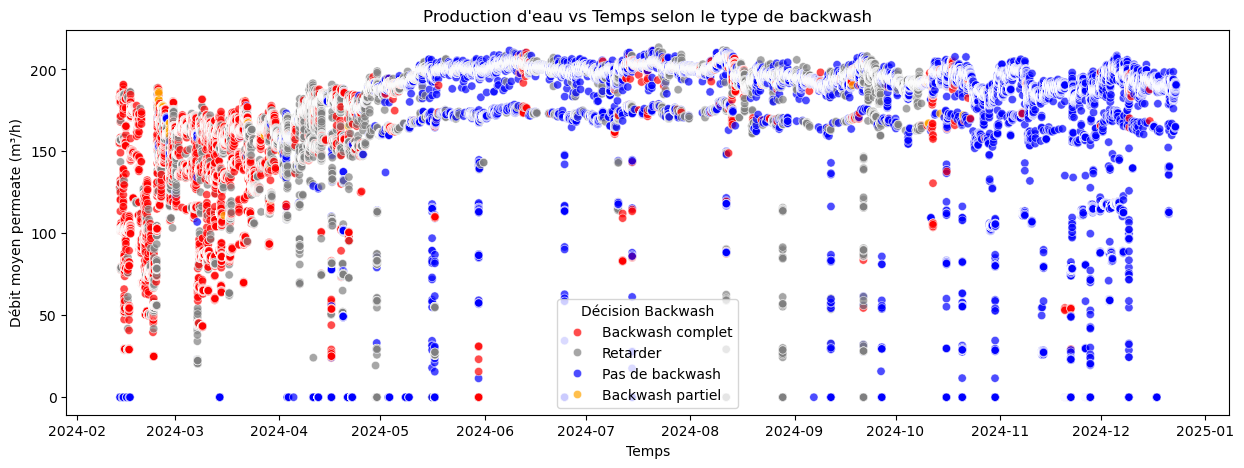

C:\Users\yass3\AppData\Local\Temp\ipykernel_13888\3406618508.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='DECISION_BACKWASH_LABEL', y='PERMEATE_TOTAL', data=df, palette='Set2')


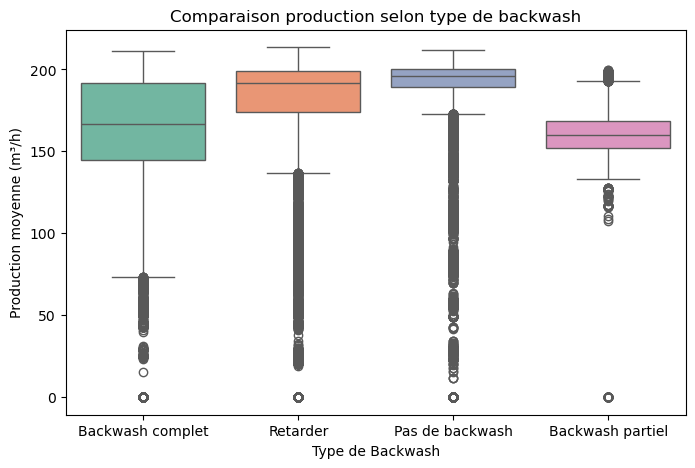

In [9]:
# 🔹 Import des librairies
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


# 🔹 Créer une colonne texte pour affichage dans les graphiques
DECISION_MAP = {
    0: "Pas de backwash",
    1: "Retarder",
    2: "Backwash partiel",
    3: "Backwash complet"
}
df['DECISION_BACKWASH_LABEL'] = df['DECISION_BACKWASH_NUM'].map(DECISION_MAP)

# 🔹 1️⃣ Graphique Production vs Temps avec Backwash
plt.figure(figsize=(15,5))
df['PERMEATE_TOTAL'] = df[[c for c in df.columns if "FIT_005" in c]].mean(axis=1)
sns.scatterplot(
    x=df.index,
    y='PERMEATE_TOTAL',
    hue='DECISION_BACKWASH_LABEL',  # utiliser le label texte
    palette={'Pas de backwash':'blue','Retarder':'gray','Backwash partiel':'orange','Backwash complet':'red'},
    data=df,
    alpha=0.7
)
plt.title("Production d'eau vs Temps selon le type de backwash")
plt.ylabel("Débit moyen permeate (m³/h)")
plt.xlabel("Temps")
plt.legend(title="Décision Backwash")
plt.show()

# 🔹 2️⃣ Boxplot Production par type de Backwash
plt.figure(figsize=(8,5))
sns.boxplot(x='DECISION_BACKWASH_LABEL', y='PERMEATE_TOTAL', data=df, palette='Set2')
plt.title("Comparaison production selon type de backwash")
plt.xlabel("Type de Backwash")
plt.ylabel("Production moyenne (m³/h)")
plt.show()


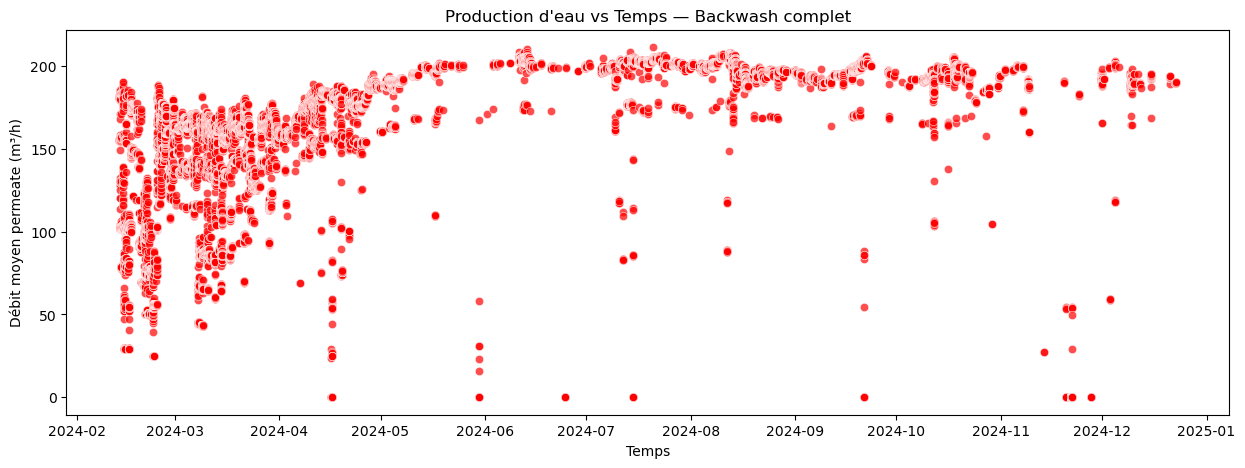

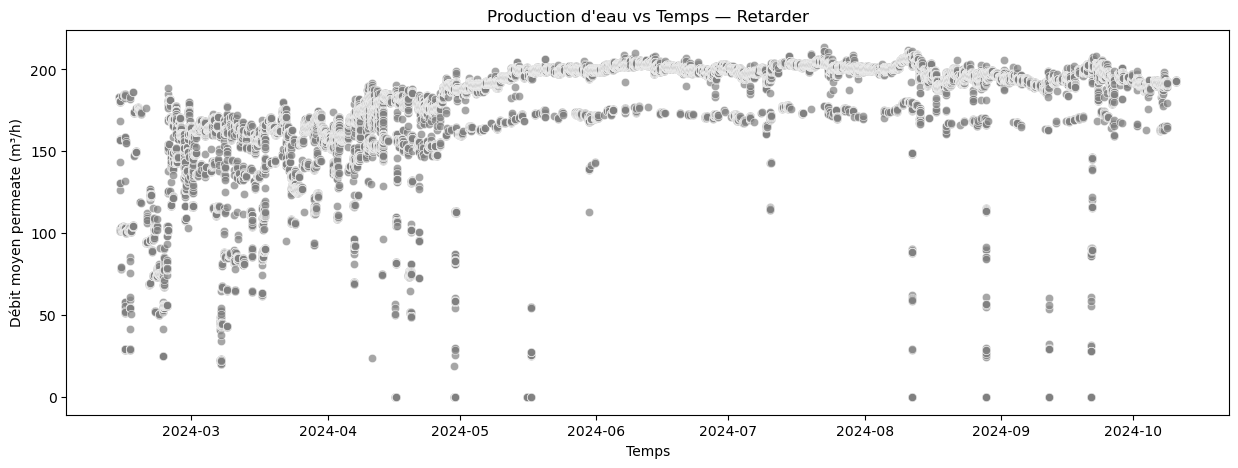

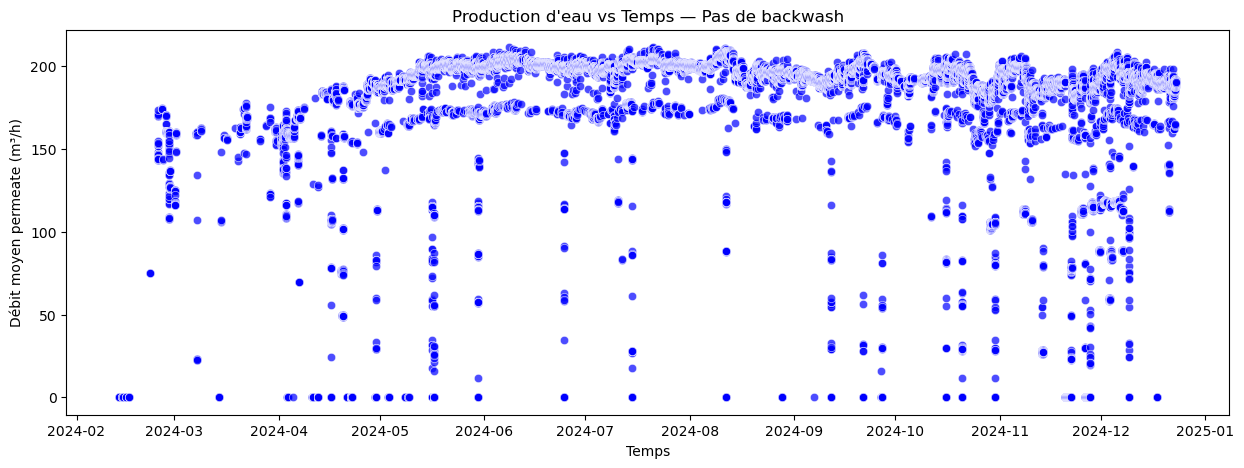

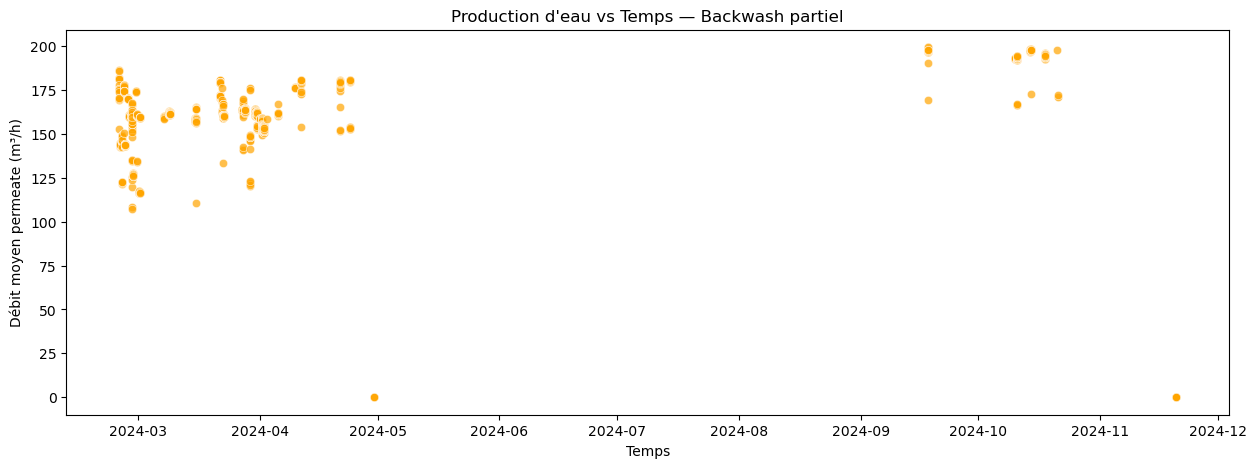

In [11]:
# Liste des types de backwash
types_backwash = df['DECISION_BACKWASH_LABEL'].unique()

# Boucle pour créer un graphique par type
for backwash in types_backwash:
    df_temp = df[df['DECISION_BACKWASH_LABEL'] == backwash]
    
    plt.figure(figsize=(15,5))
    sns.scatterplot(
        x=df_temp.index,
        y=df_temp['PERMEATE_TOTAL'],
        color='orange' if backwash=="Backwash partiel" else 
              'red' if backwash=="Backwash complet" else
              'blue' if backwash=="Pas de backwash" else
              'gray',
        alpha=0.7
    )
    plt.title(f"Production d'eau vs Temps — {backwash}")
    plt.ylabel("Débit moyen permeate (m³/h)")
    plt.xlabel("Temps")
    plt.show()


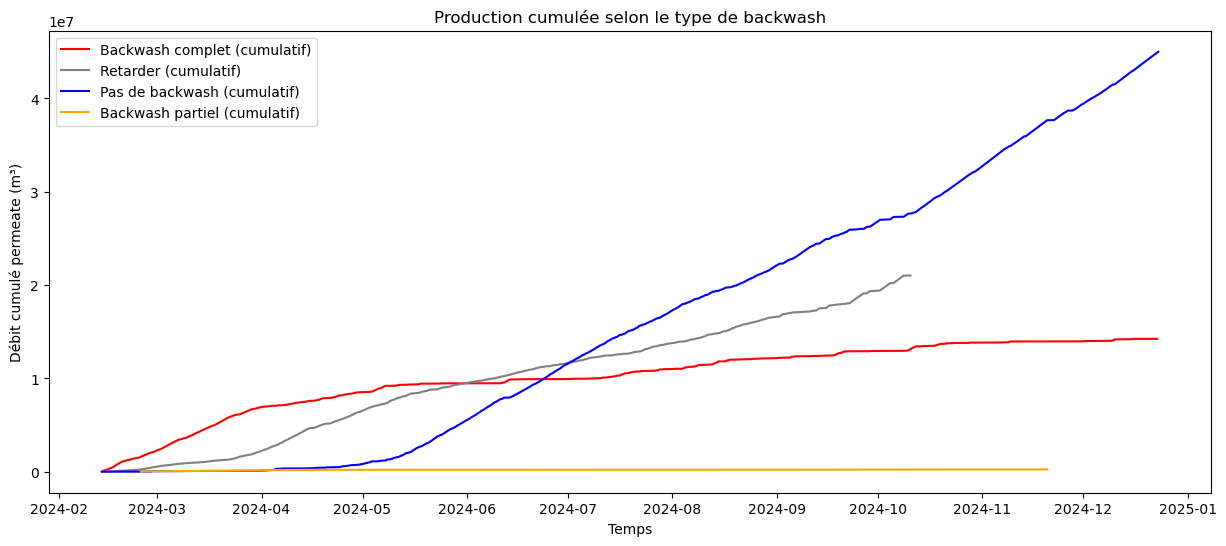

In [15]:
# Créer un dictionnaire pour stocker les données cumulatives
cumul_prod = {}

# Boucle sur chaque mode
for mode in df['DECISION_BACKWASH_LABEL'].unique():
    df_mode = df[df['DECISION_BACKWASH_LABEL'] == mode].copy()
    df_mode['CUM_PROD'] = df_mode['PERMEATE_TOTAL'].cumsum()  # production cumulée
    cumul_prod[mode] = df_mode

# Tracer toutes les courbes sur le même graphique
plt.figure(figsize=(15,6))
palette = {
    "Pas de backwash": "blue",
    "Retarder": "gray",
    "Backwash partiel": "orange",
    "Backwash complet": "red"
}

for mode, df_mode in cumul_prod.items():
    plt.plot(df_mode.index, df_mode['CUM_PROD'], color=palette.get(mode,"black"), label=f"{mode} (cumulatif)")

plt.title("Production cumulée selon le type de backwash")
plt.xlabel("Temps")
plt.ylabel("Débit cumulé permeate (m³)")
plt.legend()
plt.show()


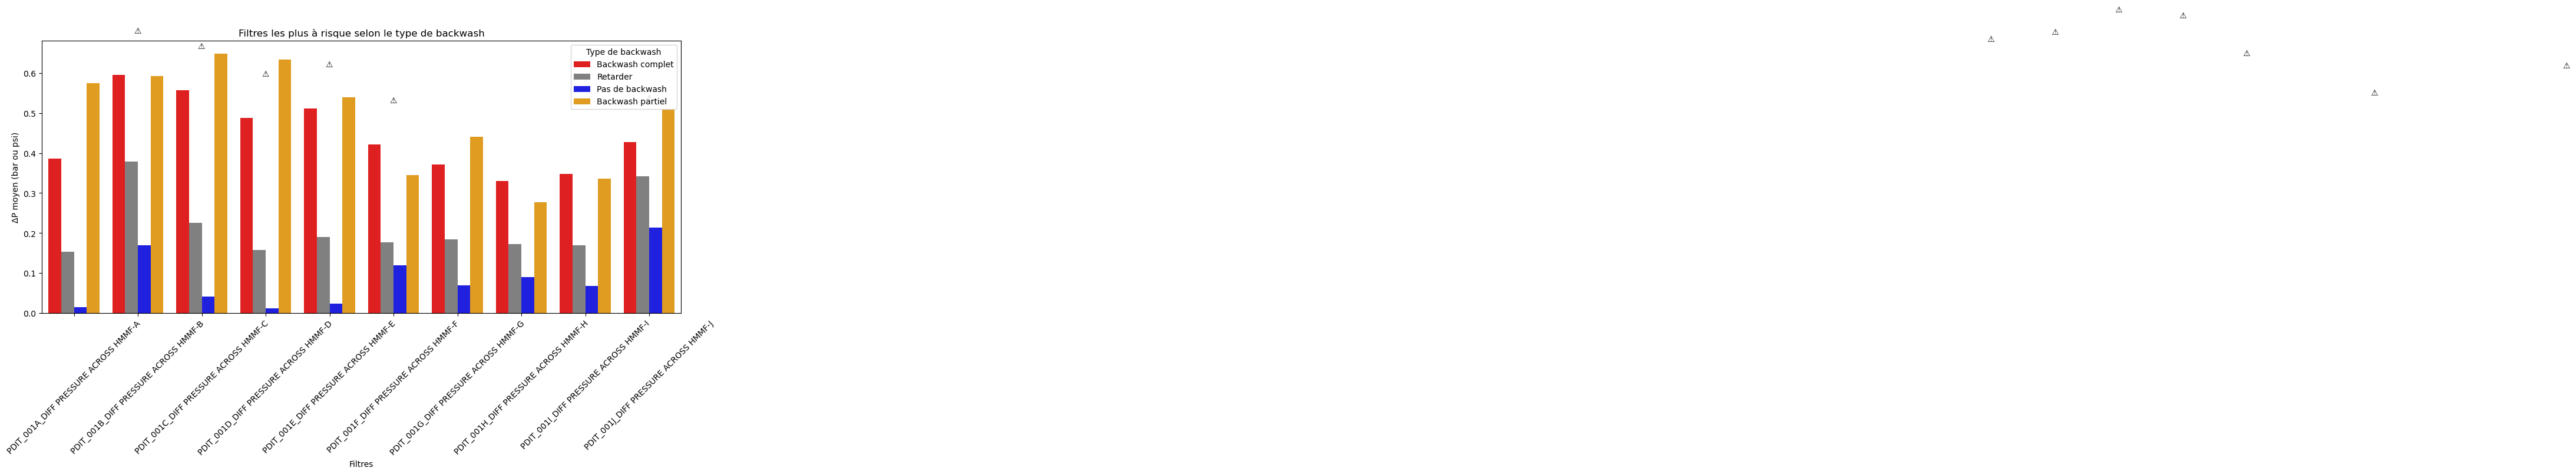

In [27]:
# Pas de filtrage strict, juste montrer tous mais annoter ceux à risque
data_risque = []

for mode in df['DECISION_BACKWASH_LABEL'].unique():
    df_mode = df[df['DECISION_BACKWASH_LABEL'] == mode]
    dp_moy_filtres = df_mode[filtres].mean()
    for filtre, dp in dp_moy_filtres.items():
        data_risque.append({
            "Filtre": filtre,
            "DP moyen": dp,
            "Type Backwash": mode,
            "Risque": dp > seuil_global  # True/False
        })

df_risque = pd.DataFrame(data_risque)

# Graphe
plt.figure(figsize=(14,6))
sns.barplot(
    x="Filtre",
    y="DP moyen",
    hue="Type Backwash",
    data=df_risque,
    palette={
        "Pas de backwash": "blue",
        "Retarder": "gray",
        "Backwash partiel": "orange",
        "Backwash complet": "red"
    }
)

# Annoter les barres à risque
for i, row in df_risque.iterrows():
    if row["Risque"]:
        plt.text(i, row["DP moyen"]+0.1, "⚠️", ha='center', va='bottom', fontsize=10)

plt.title("Filtres les plus à risque selon le type de backwash")
plt.ylabel("ΔP moyen (bar ou psi)")
plt.xlabel("Filtres")
plt.xticks(rotation=45)
plt.legend(title="Type de backwash")
plt.show()


In [37]:
# Dictionnaire filtres → colonnes ΔP
FILTRES_PDIT = {
    "HMMF-A": "PDIT_001A_DIFF PRESSURE ACROSS HMMF-A",
    "HMMF-B": "PDIT_001B_DIFF PRESSURE ACROSS HMMF-B",
    "HMMF-C": "PDIT_001C_DIFF PRESSURE ACROSS HMMF-C",
    "HMMF-D": "PDIT_001D_DIFF PRESSURE ACROSS HMMF-D",
    "HMMF-E": "PDIT_001E_DIFF PRESSURE ACROSS HMMF-E",
    "HMMF-F": "PDIT_001F_DIFF PRESSURE ACROSS HMMF-F",
    "HMMF-G": "PDIT_001G_DIFF PRESSURE ACROSS HMMF-G",
    "HMMF-H": "PDIT_001H_DIFF PRESSURE ACROSS HMMF-H",
    "HMMF-I": "PDIT_001I_DIFF PRESSURE ACROSS HMMF-I",
    "HMMF-J": "PDIT_001J_DIFF PRESSURE ACROSS HMMF-J",
}


C:\Users\yass3\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


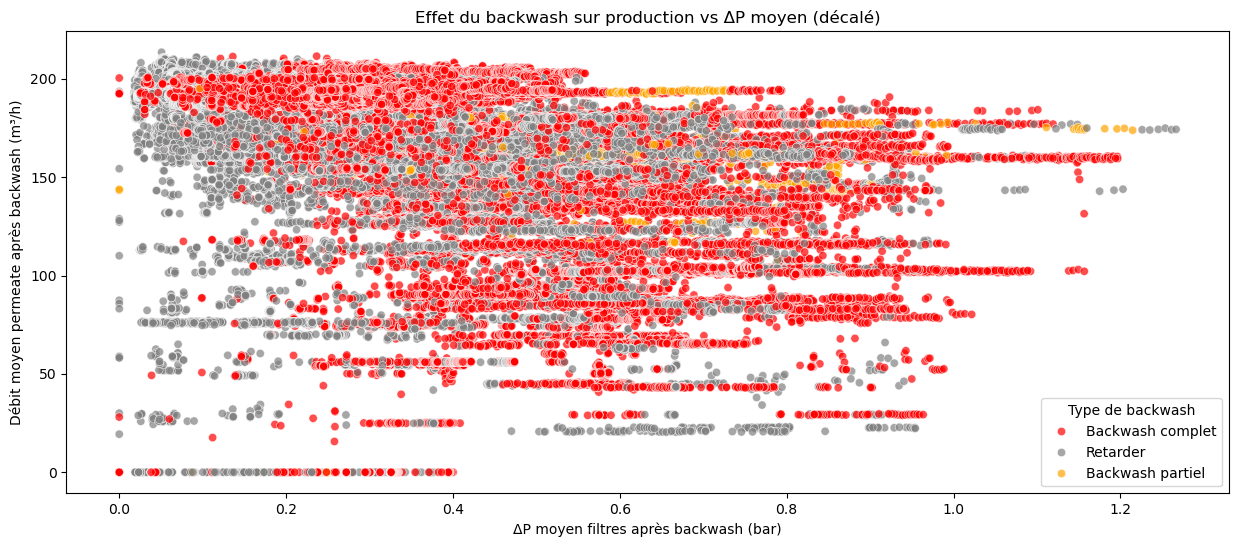

In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 🔹 Créer une colonne "PERMEATE_TOTAL"
df['PERMEATE_TOTAL'] = df[[c for c in df.columns if "FIT_005" in c]].mean(axis=1)

# 🔹 Décalage pour observer l'effet du backwash (ex: 6 pas de temps = 30 min)
# Ajuste le nombre selon ton pas de temps réel
decalage = 6
df['PERMEATE_AFTER_BACKWASH'] = df['PERMEATE_TOTAL'].shift(-decalage)
df['DP_MOYEN_AFTER_BACKWASH'] = df[[c for c in FILTRES_PDIT.values()]].mean(axis=1).shift(-decalage)

# 🔹 Filtrer les lignes où on prend une décision de backwash
df_backwash = df[df['DECISION_BACKWASH_LABEL'] != 'Pas de backwash']

# 🔹 Graphe production après backwash vs ΔP moyen après backwash
plt.figure(figsize=(15,6))
sns.scatterplot(
    x='DP_MOYEN_AFTER_BACKWASH',
    y='PERMEATE_AFTER_BACKWASH',
    hue='DECISION_BACKWASH_LABEL',
    palette={'Retarder':'gray','Backwash partiel':'orange','Backwash complet':'red'},
    data=df_backwash,
    alpha=0.7
)

plt.title("Effet du backwash sur production vs ΔP moyen (décalé)")
plt.xlabel("ΔP moyen filtres après backwash (bar)")
plt.ylabel("Débit moyen permeate après backwash (m³/h)")
plt.legend(title="Type de backwash")
plt.show()


In [43]:
# 🔹 Colonnes PDIT
filtres = list(FILTRES_PDIT.values())

# 🔹 Décalage (effet backwash)
decalage = 6  # à adapter selon ton pas de temps

# 🔹 Créer PDIT après backwash (décalé)
for col in filtres:
    df[col + "_AFTER"] = df[col].shift(-decalage)

# 🔹 Seuil global de risque (sur ΔP après)
seuil_global = df[[c + "_AFTER" for c in filtres]].quantile(0.75).mean()

# 🔹 Construction du dataset risque
data_risque = []

for mode in df['DECISION_BACKWASH_LABEL'].unique():
    df_mode = df[df['DECISION_BACKWASH_LABEL'] == mode]

    for filtre, col in FILTRES_PDIT.items():
        dp_apres = df_mode[col + "_AFTER"].mean()

        data_risque.append({
            "Filtre": filtre,
            "DP moyen après backwash": dp_apres,
            "Type Backwash": mode,
            "Risque": dp_apres > seuil_global
        })

df_risque = pd.DataFrame(data_risque)


In [45]:
df.shape

(449002, 113)

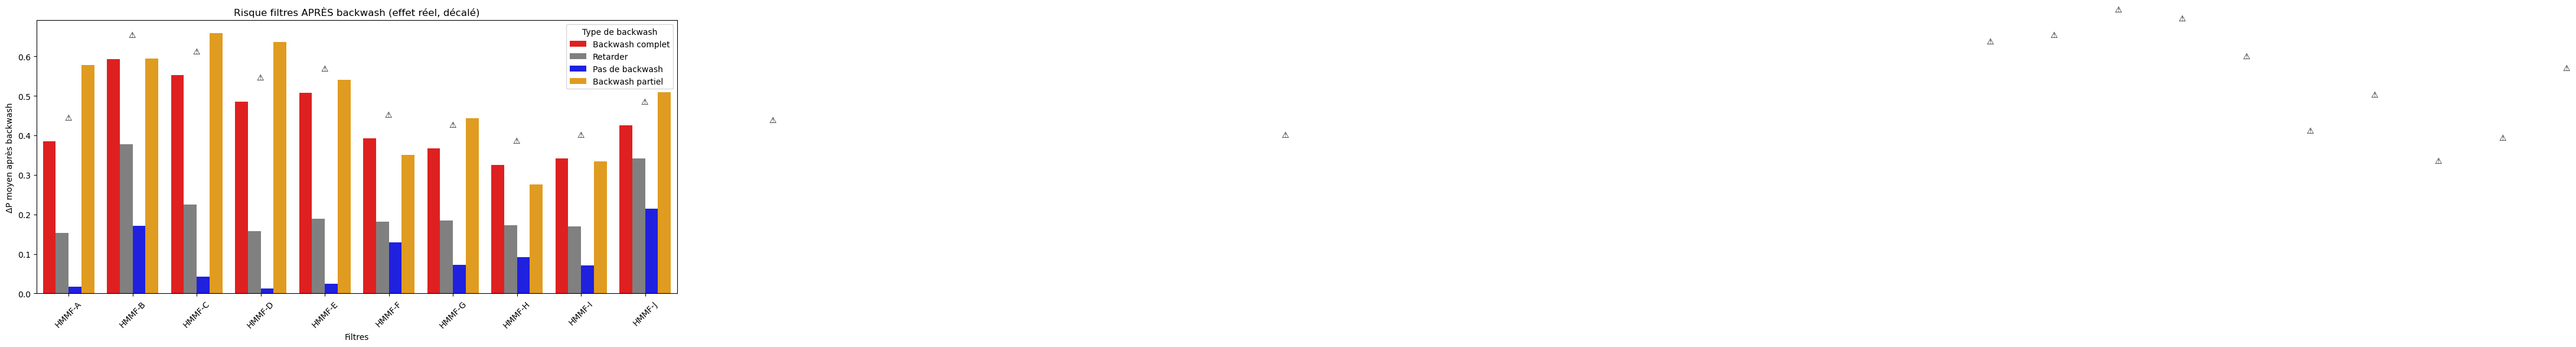

In [47]:
plt.figure(figsize=(14,6))
sns.barplot(
    x="Filtre",
    y="DP moyen après backwash",
    hue="Type Backwash",
    data=df_risque,
    palette={
        "Pas de backwash": "blue",
        "Retarder": "gray",
        "Backwash partiel": "orange",
        "Backwash complet": "red"
    }
)

# ⚠️ Annotation danger
for i, row in df_risque.iterrows():
    if row["Risque"]:
        plt.text(i, row["DP moyen après backwash"] + 0.05, "⚠️",
                 ha="center", va="bottom", fontsize=10)

plt.title("Risque filtres APRÈS backwash (effet réel, décalé)")
plt.ylabel("ΔP moyen après backwash")
plt.xlabel("Filtres")
plt.xticks(rotation=45)
plt.legend(title="Type de backwash")
plt.show()


In [65]:
print(df['DECISION_BACKWASH_LABEL'].value_counts())

DECISION_BACKWASH_LABEL
Pas de backwash     241807
Retarder            116105
Backwash complet     89504
Backwash partiel      1586
Name: count, dtype: int64


In [75]:
# Supprimer les 5 dernières colonnes du DataFrame
df = df.iloc[:, :-2]


In [77]:
df.head()

,INTAKE LINE PRESSURE OF HMMF FEED PUMPS,FIT_001A_FLOW AT INLET HMMF-A,FIT_001B_FLOW AT INLET HMMF-B,FIT_001C_FLOW AT INLET HMMF-C,FIT_001D_FLOW AT INLET HMMF-D,FIT_001E_FLOW AT INLET HMMF-E,FIT_001F_FLOW AT INLET HMMF-F,FIT_001G_FLOW AT INLET HMMF-G,FIT_001H_FLOW AT INLET HMMF-H,FIT_001I_FLOW AT INLET HMMF-I,...,FIT_005F_PERMEATE FLOW,FIT_005G_PERMEATE FLOW,FIT_005H_PERMEATE FLOW,INDICE_ENCRASSEMENT_HMMF,DEBIT_ENTREE_HMMF,INDICE_IMPACT_PRODUCTION,INDICE_DESEQUILIBRE_FILTRES,DECISION_BACKWASH_NUM,FILTRES_A_BACKWASHER,PERMEATE_TOTAL
time,,,,,,,,,,,,,,,,,,,,,
2024-02-13 11:38:00,1.49075,454.837494,391.059570,494.862335,388.456238,371.231262,452.521881,391.543762,452.603119,403.975006,...,195.278122,198.515625,164.696869,0.695475,415.330942,0.001675,0.100190,3,"['HMMF-A', 'HMMF-B', 'HMMF-C', 'HMMF-D', 'HMMF...",181.096874
2024-02-13 11:39:00,1.49650,454.837494,388.655182,493.031921,388.496887,369.078125,452.521881,391.421875,451.587494,403.812500,...,196.524994,198.515625,167.453125,0.694425,414.367148,0.001676,0.099537,3,"['HMMF-A', 'HMMF-B', 'HMMF-C', 'HMMF-D', 'HMMF...",181.671875
2024-02-13 11:40:00,1.49525,454.837494,386.984314,493.642059,388.984375,368.468750,452.521881,389.715637,449.596863,401.821869,...,196.153122,198.515625,165.746872,0.693700,413.566388,0.001677,0.099028,3,"['HMMF-A', 'HMMF-B', 'HMMF-C', 'HMMF-D', 'HMMF...",181.543749
2024-02-13 11:41:00,1.49625,454.837494,386.413788,492.259064,386.181244,367.981262,452.521881,390.040619,450.165619,400.968750,...,197.115631,198.515625,167.803131,0.692450,412.985098,0.001677,0.097855,3,"['HMMF-A', 'HMMF-B', 'HMMF-C', 'HMMF-D', 'HMMF...",181.581251
2024-02-13 11:42:00,1.50775,454.837494,387.391846,490.632050,387.968750,370.012512,452.521881,388.862488,450.409363,400.359375,...,195.409378,198.515625,168.000000,0.693088,413.029889,0.001678,0.097786,3,"['HMMF-A', 'HMMF-B', 'HMMF-C', 'HMMF-D', 'HMMF...",181.750000


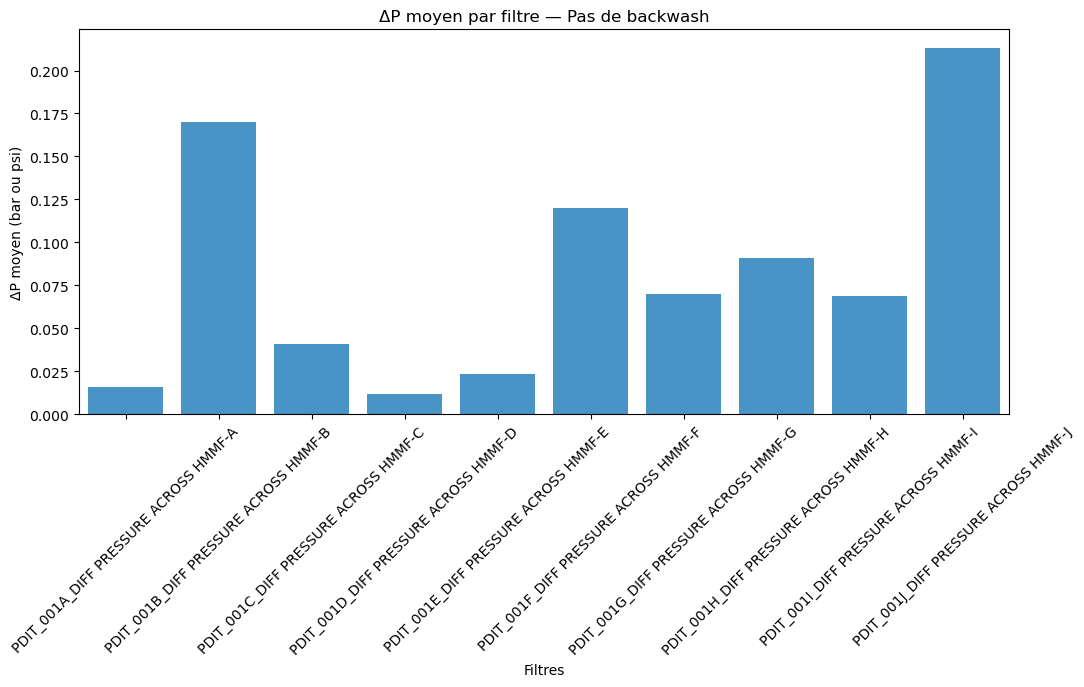

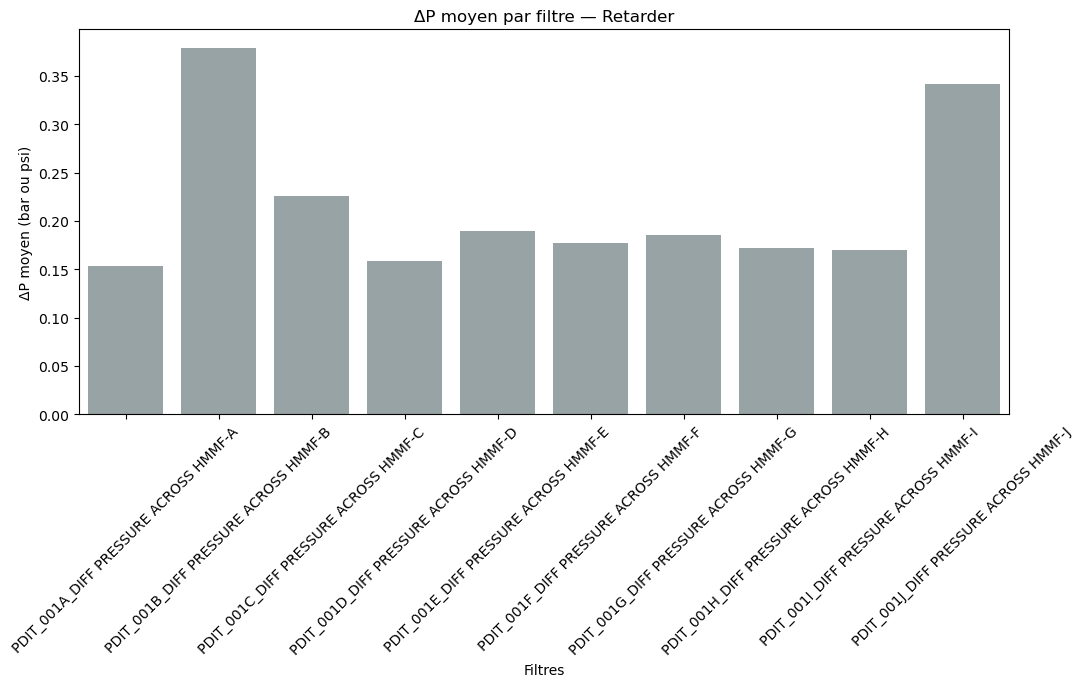

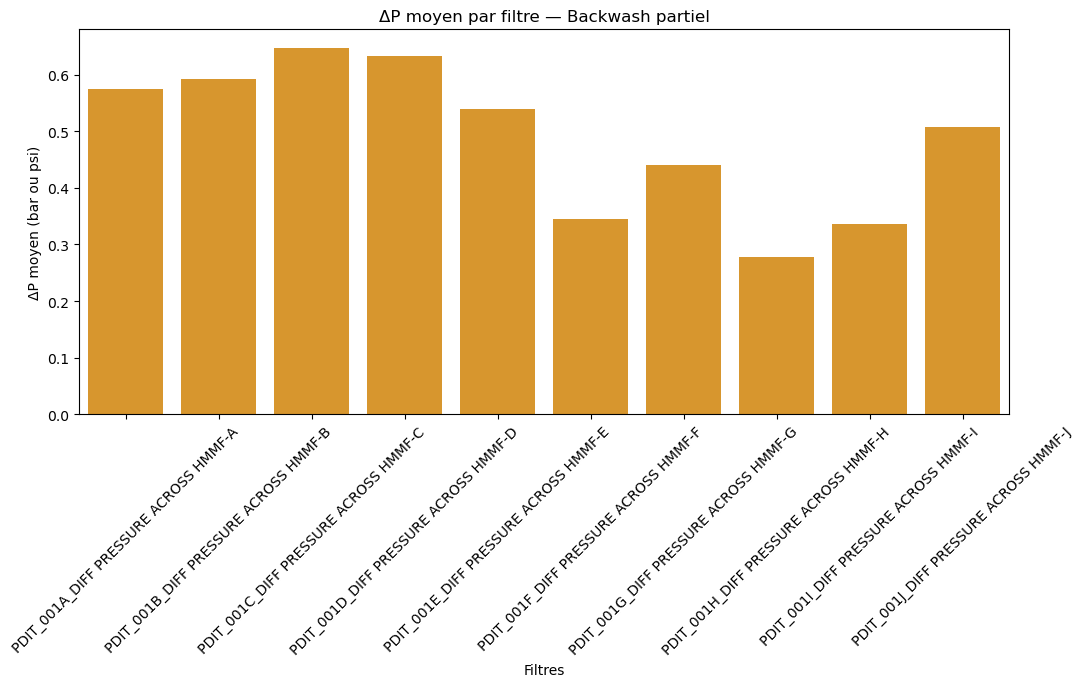

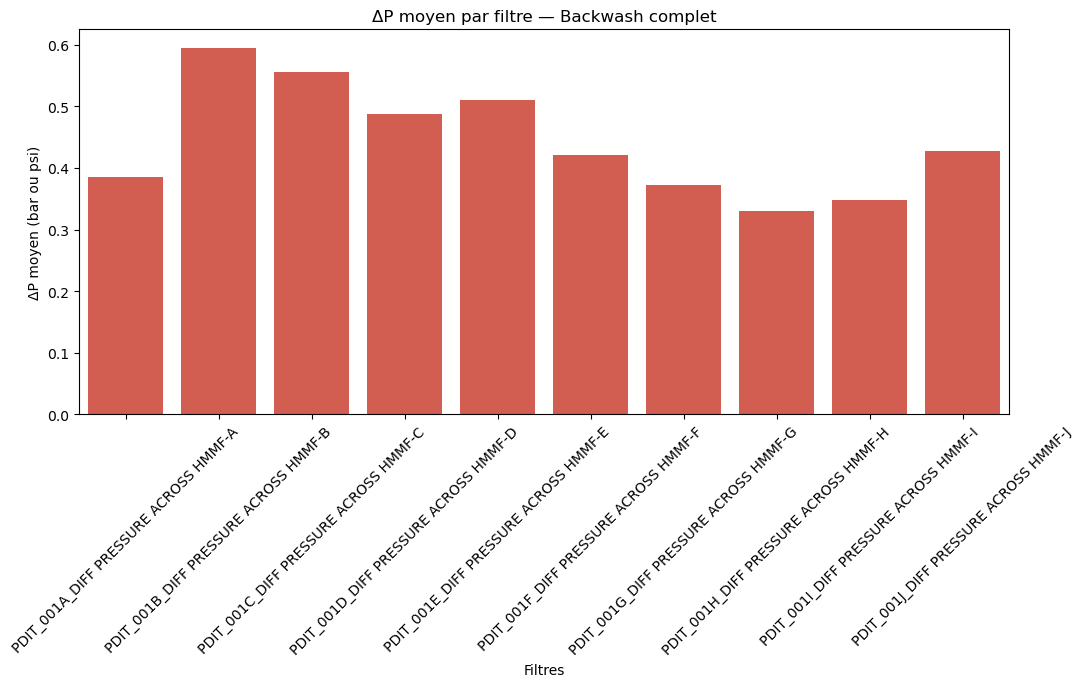

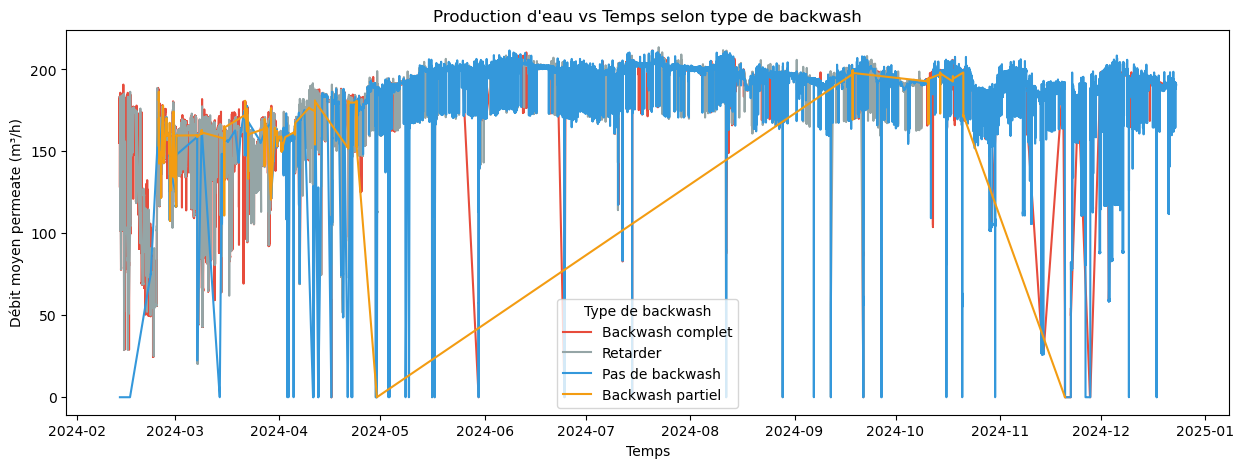

C:\Users\yass3\AppData\Local\Temp\ipykernel_13888\3975932324.py:86: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


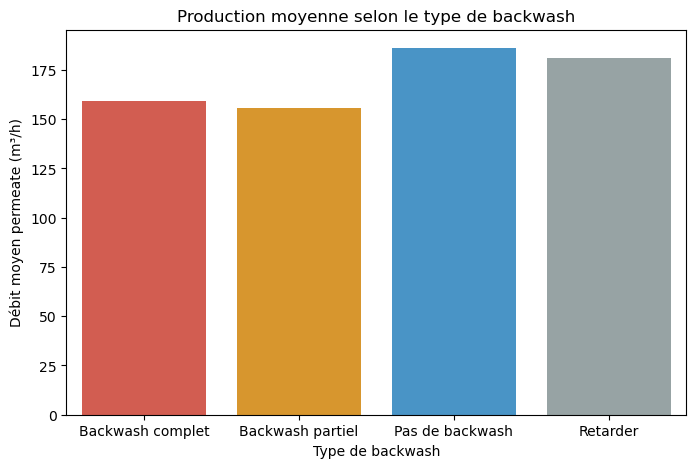

In [83]:
# 🔹 Imports nécessaires
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# 🔹 Créer un mapping numérique → label
mapping_backwash = {
    0: "Pas de backwash",
    1: "Retarder",
    2: "Backwash partiel",
    3: "Backwash complet"
}

# 🔹 Ajouter la colonne label texte
df['DECISION_BACKWASH_LABEL'] = df['DECISION_BACKWASH_NUM'].map(mapping_backwash)

# 🔹 Vérifier
df[['DECISION_BACKWASH_NUM','DECISION_BACKWASH_LABEL']].head()

# 🔹 Colonnes filtres
FILTRES_PDIT = {
    "HMMF-A": "PDIT_001A_DIFF PRESSURE ACROSS HMMF-A",
    "HMMF-B": "PDIT_001B_DIFF PRESSURE ACROSS HMMF-B",
    "HMMF-C": "PDIT_001C_DIFF PRESSURE ACROSS HMMF-C",
    "HMMF-D": "PDIT_001D_DIFF PRESSURE ACROSS HMMF-D",
    "HMMF-E": "PDIT_001E_DIFF PRESSURE ACROSS HMMF-E",
    "HMMF-F": "PDIT_001F_DIFF PRESSURE ACROSS HMMF-F",
    "HMMF-G": "PDIT_001G_DIFF PRESSURE ACROSS HMMF-G",
    "HMMF-H": "PDIT_001H_DIFF PRESSURE ACROSS HMMF-H",
    "HMMF-I": "PDIT_001I_DIFF PRESSURE ACROSS HMMF-I",
    "HMMF-J": "PDIT_001J_DIFF PRESSURE ACROSS HMMF-J",
}

# 🔹 Ajouter production totale moyenne
df['PERMEATE_TOTAL'] = df[[c for c in df.columns if "FIT_005" in c]].mean(axis=1)

# 🔹 Fonction pour graphe ΔP moyen par filtre selon mode de backwash
def plot_dp_filtres(mode, color, df_plot):
    df_mode = df_plot[df_plot['DECISION_BACKWASH_LABEL'] == mode]
    dp_moy = df_mode[list(FILTRES_PDIT.values())].mean()
    
    plt.figure(figsize=(12,5))
    sns.barplot(x=dp_moy.index, y=dp_moy.values, color=color)
    plt.title(f"ΔP moyen par filtre — {mode}")
    plt.ylabel("ΔP moyen (bar ou psi)")
    plt.xlabel("Filtres")
    plt.xticks(rotation=45)
    plt.show()

# 🔹 1️⃣ Pas de backwash
plot_dp_filtres("Pas de backwash", "#3498db", df)

# 🔹 2️⃣ Retarder
plot_dp_filtres("Retarder", "#95a5a6", df)

# 🔹 3️⃣ Backwash partiel
plot_dp_filtres("Backwash partiel", "#f39c12", df)

# 🔹 4️⃣ Backwash complet
plot_dp_filtres("Backwash complet", "#e74c3c", df)

# 🔹 Graphe production vs temps selon type de backwash
plt.figure(figsize=(15,5))
sns.lineplot(
    x=df.index,
    y='PERMEATE_TOTAL',
    hue='DECISION_BACKWASH_LABEL',
    palette={
        "Pas de backwash":"#3498db",
        "Retarder":"#95a5a6",
        "Backwash partiel":"#f39c12",
        "Backwash complet":"#e74c3c"
    },
    data=df
)
plt.title("Production d'eau vs Temps selon type de backwash")
plt.ylabel("Débit moyen permeate (m³/h)")
plt.xlabel("Temps")
plt.legend(title="Type de backwash")
plt.show()

# 🔹 Graphe comparaison production moyenne par type de backwash
prod_moy = df.groupby("DECISION_BACKWASH_LABEL")['PERMEATE_TOTAL'].mean().reset_index()
plt.figure(figsize=(8,5))
sns.barplot(
    x="DECISION_BACKWASH_LABEL",
    y="PERMEATE_TOTAL",
    data=prod_moy,
    palette={
        "Pas de backwash":"#3498db",
        "Retarder":"#95a5a6",
        "Backwash partiel":"#f39c12",
        "Backwash complet":"#e74c3c"
    }
)
plt.title("Production moyenne selon le type de backwash")
plt.ylabel("Débit moyen permeate (m³/h)")
plt.xlabel("Type de backwash")
plt.show()


In [85]:
import pandas as pd

# 🔹 Calcul pression moyenne des filtres
df['DP_moy'] = df[list(FILTRES_PDIT.values())].mean(axis=1)

# 🔹 Nouveau dataset avec seulement les colonnes nécessaires
df_new = pd.DataFrame({
    "Time": df.index,
    "Production_totale": df['PERMEATE_TOTAL'],
    "DP_moyen_filtres": df['DP_moy'],
    "DECISION_BACKWASH_NUM": df['DECISION_BACKWASH_NUM'],
    "DECISION_BACKWASH_LABEL": df['DECISION_BACKWASH_LABEL'],
    "Filtres_cibles": df['FILTRES_A_BACKWASHER'],
    "Niveau_reservoir": df['LIT_002_FILTER_WATER_STG_TNK']
})

# 🔹 Vérifier
df_new.head(20)

# 🔹 Enregistrer
df_new.to_csv("dataset_backwash_essentiel.csv", index=False)
